In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay, roc_auc_score

In [29]:
import warnings

warnings.filterwarnings("ignore")

In [16]:
df = pd.read_csv('onlinefraud_cleaned.csv')
df.head(10)

,hour_of_day,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig,nameDest,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.0,0.00,C1231006815,M1979787155,1,0.00,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.0,0.00,C1666544295,M2044282225,1,0.00,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.0,0.00,C1305486145,C553264065,0,0.00,181.00,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.0,0.00,C840083671,C38997010,0,0.00,21363.00,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.0,0.00,C2048537720,M1230701703,1,0.00,0.00,0
5,1,PAYMENT,7817.71,53860.00,46042.29,0.0,0.00,C90045638,M573487274,1,0.00,0.00,0
6,1,PAYMENT,7107.77,183195.00,176087.23,0.0,0.00,C154988899,M408069119,1,0.00,0.00,0
7,1,PAYMENT,7861.64,176087.23,168225.59,0.0,0.00,C1912850431,M633326333,1,0.00,0.00,0
8,1,PAYMENT,4024.36,2671.00,0.00,0.0,0.00,C1265012928,M1176932104,1,1353.36,0.00,0
9,1,DEBIT,5337.77,41720.00,36382.23,41898.0,40348.79,C712410124,C195600860,0,0.00,6886.98,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df = pd.get_dummies(df, columns= ['type'], drop_first= True, dtype= int)

In [19]:
df

,hour_of_day,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig,nameDest,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.00,0.00,C1231006815,M1979787155,1,0.0,0.000000e+00,0,0,0,1,0
1,1,1864.28,21249.00,19384.72,0.00,0.00,C1666544295,M2044282225,1,0.0,0.000000e+00,0,0,0,1,0
2,1,181.00,181.00,0.00,0.00,0.00,C1305486145,C553264065,0,0.0,1.810000e+02,1,0,0,0,1
3,1,181.00,181.00,0.00,21182.00,0.00,C840083671,C38997010,0,0.0,2.136300e+04,1,1,0,0,0
4,1,11668.14,41554.00,29885.86,0.00,0.00,C2048537720,M1230701703,1,0.0,0.000000e+00,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,23,339682.13,339682.13,0.00,0.00,339682.13,C786484425,C776919290,0,0.0,0.000000e+00,1,1,0,0,0
6362616,23,6311409.28,6311409.28,0.00,0.00,0.00,C1529008245,C1881841831,0,0.0,6.311409e+06,1,0,0,0,1
6362617,23,6311409.28,6311409.28,0.00,68488.84,6379898.11,C1162922333,C1365125890,0,0.0,1.000000e-02,1,1,0,0,0
6362618,23,850002.52,850002.52,0.00,0.00,0.00,C1685995037,C2080388513,0,0.0,8.500025e+05,1,0,0,0,1


In [20]:
X = df.drop(['nameOrig', 'nameDest'], axis= 1)
y = X.pop('isFraud')

# train+val and test
x_temp, x_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# train and validation
x_train, x_val, y_train, y_val = train_test_split(
    x_temp,
    y_temp,
    test_size=0.1765,  # ~15% total
    stratify=y_temp,
    random_state=42
)

scaler = StandardScaler()

# Fit only on training data
x_train_scaled = scaler.fit_transform(x_train)

# Use the same scaler for val and test
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# Keep only 1 million rows
# Sample for model comparison
X_sample, _, y_sample, _ = train_test_split(
    x_train_scaled,
    y_train,
    train_size=1_000_000,
    stratify=y_train,
    random_state=42
)

X_sample.shape, y_sample.shape

((1000000, 13), (1000000,))

In [21]:
x_train_scaled.shape, x_val_scaled.shape, x_test_scaled.shape

((4453674, 13), (954553, 13), (954393, 13))

In [22]:
def model_comparison_evaluate(classifiers, X, y, n_splits=5):
    """
    Compare multiple classification models using Stratified K-Fold Cross Validation.

    Parameters
    ----------
    classifiers : dict
        Dictionary containing model names and model objects.

        Example:
        {
            'Logistic Regression': LogisticRegression(),
            'Random Forest': RandomForestClassifier()
        }

    X : pandas.DataFrame, pandas.Series, numpy.ndarray
        Feature matrix (input variables).

        Accepted formats:
        - pandas DataFrame
        - pandas Series
        - NumPy array

        Shape:
        (n_samples, n_features)

    y : pandas.Series, numpy.ndarray, list
        Target labels.

        Accepted formats:
        - pandas Series
        - NumPy array
        - Python list

        Shape:
        (n_samples,)

    n_splits : int, default=5
        Number of folds for cross-validation.

    Returns
    -------
    None
        Prints evaluation results for each model.
    """

    # Stratified K-Fold keeps class distribution balanced
    skfold = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    # PR-AUC scorer
    pr_auc_scorer = make_scorer(
        average_precision_score,
        response_method='predict_proba'
    )

    scoring_metrics = {
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'pr_auc': pr_auc_scorer
    }

    print('K-Fold Cross-Validation Evaluation\n')

    for name, model in classifiers.items():

        print('=' * 50)
        print(f'Model: {name}')
        print('=' * 50)

        for metric_name, scoring_method in scoring_metrics.items():

            scores = cross_val_score(
                estimator=model,
                X=X,
                y=y,
                scoring=scoring_method,
                cv=skfold,
                n_jobs= -1
            )

            print(
                f'{metric_name:<10}: '
                f'Mean = {scores.mean():.4f} | '
                f'Std = {scores.std():.4f}'
            )

        print('\n')

In [23]:
classifiers = {

    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_depth=10,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=10,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    ),

    'CatBoost': CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=10,
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0,
    )
}

In [24]:
model_comparison_evaluate(classifiers, X_sample, y_sample)

K-Fold Cross-Validation Evaluation

Model: Logistic Regression
precision : Mean = 0.0244 | Std = 0.0008
recall    : Mean = 0.8916 | Std = 0.0268
f1        : Mean = 0.0474 | Std = 0.0016
roc_auc   : Mean = 0.9820 | Std = 0.0024
pr_auc    : Mean = 0.5299 | Std = 0.0253


Model: Random Forest
precision : Mean = 1.0000 | Std = 0.0000
recall    : Mean = 0.9907 | Std = 0.0031
f1        : Mean = 0.9953 | Std = 0.0016
roc_auc   : Mean = 0.9961 | Std = 0.0012
pr_auc    : Mean = 0.9922 | Std = 0.0026


Model: Extra Trees
precision : Mean = 0.9935 | Std = 0.0047
recall    : Mean = 0.8273 | Std = 0.0138
f1        : Mean = 0.9027 | Std = 0.0088
roc_auc   : Mean = 0.9960 | Std = 0.0012
pr_auc    : Mean = 0.9646 | Std = 0.0082


Model: HistGradientBoosting
precision : Mean = 0.9953 | Std = 0.0038
recall    : Mean = 0.9884 | Std = 0.0069
f1        : Mean = 0.9918 | Std = 0.0034
roc_auc   : Mean = 0.9979 | Std = 0.0021
pr_auc    : Mean = 0.9898 | Std = 0.0050


Model: XGBoost
precision : Mean = 0.9370 

In [39]:
lr_model = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )

rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

lgbm_model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    )
# Logistic Regression
lr_model.fit(x_train_scaled, y_train)

# Random Forest
rf_model.fit(x_train_scaled, y_train)

# Light GBM
lgbm_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
    eval_metric='auc'
)

[LightGBM] [Info] Number of positive: 5749, number of negative: 4447925
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1825
[LightGBM] [Info] Number of data points in the train set: 4453674, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [43]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "LightGBM": lgbm_model
}

for name, model in models.items():
    pred_proba = model.predict_proba(x_val_scaled)[:, 1]
    auc_score = roc_auc_score(y_val, pred_proba)
    print(f"{name}: {auc_score:.4f}")

Logistic Regression: 0.9910
Random Forest: 0.9996
LightGBM: 1.0000


In [54]:
# Logistic Regression
lr_y_pred = lr_model.predict(x_test_scaled)
lr_y_pred_score = lr_model.predict_proba(x_test_scaled)[:, 1]

print("===========================================================")
print("Logistic Regression:")
print(
    classification_report(
        y_test,
        lr_y_pred,
        digits= 4,
        labels=[0, 1],
        target_names=['Non-Fraud', 'Fraud']
    )
)
print("===========================================================")


# Random Forest
rf_y_pred = rf_model.predict(x_test_scaled)
rf_y_pred_score = rf_model.predict_proba(x_test_scaled)[:, 1]

print("Random Forest:")
print(
    classification_report(
        y_test,
        rf_y_pred,
        digits= 4,
        labels=[0, 1],
        target_names=['Non-Fraud', 'Fraud']
    )
)
print("===========================================================")

# Light GBM
lgbm_y_pred = lgbm_model.predict(x_test_scaled)
lgbm_y_pred_score = lgbm_model.predict_proba(x_test_scaled)[:,1]

print("LightGBM:")
print(
    classification_report(
        y_test,
        lgbm_y_pred,
        digits=4,
        labels= [0, 1],
        target_names= ['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

Logistic Regression:
              precision    recall  f1-score   support

   Non-Fraud     0.9999    0.9522    0.9755    953161
       Fraud     0.0249    0.9432    0.0485      1232

    accuracy                         0.9522    954393
   macro avg     0.5124    0.9477    0.5120    954393
weighted avg     0.9987    0.9522    0.9743    954393

Random Forest:
              precision    recall  f1-score   support

   Non-Fraud     1.0000    1.0000    1.0000    953161
       Fraud     1.0000    0.9976    0.9988      1232

    accuracy                         1.0000    954393
   macro avg     1.0000    0.9988    0.9994    954393
weighted avg     1.0000    1.0000    1.0000    954393

LightGBM:
              precision    recall  f1-score   support

   Non-Fraud     1.0000    1.0000    1.0000    953161
       Fraud     0.9951    0.9976    0.9964      1232

    accuracy                         1.0000    954393
   macro avg     0.9976    0.9988    0.9982    954393
weighted avg     1.0000    1

#### Logistic Regression

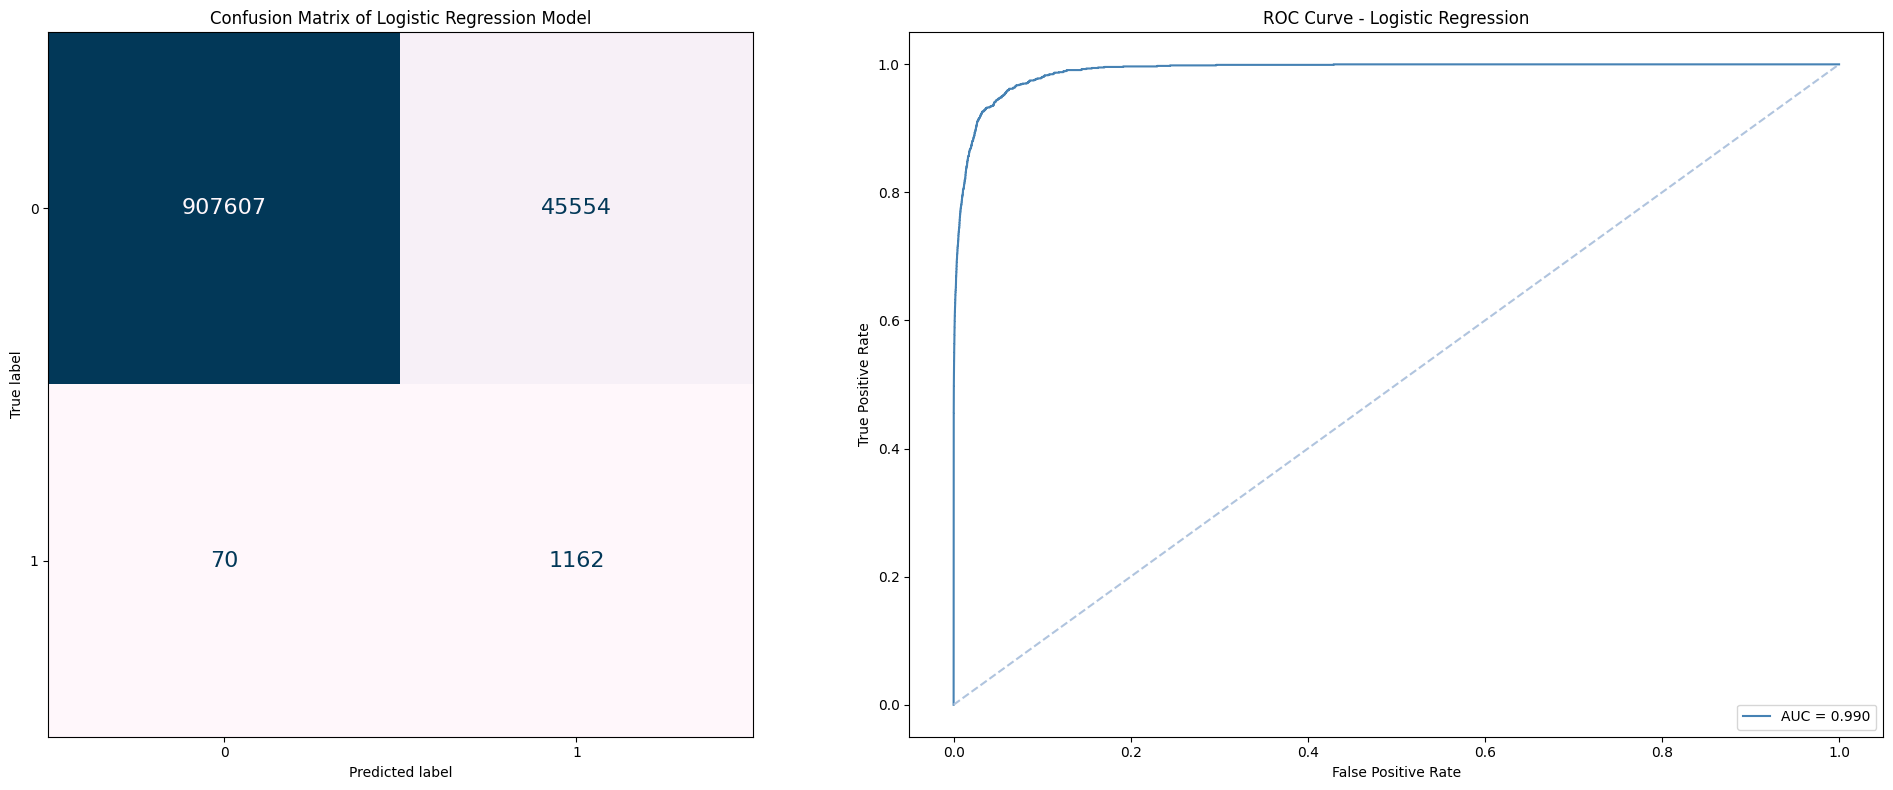

In [57]:
from sklearn.metrics import auc
fig, ax = plt.subplots(1, 2, figsize=(20,8))

# Confusion Matrix
ax[0].set_title('Confusion Matrix of Logistic Regression Model')
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_y_pred,
    colorbar=False,
    values_format='',
    cmap='PuBu',
    ax=ax[0],
    text_kw={'fontsize': 16}
)
ax[0].grid(False)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, lr_y_pred_score)
roc_auc = auc(fpr, tpr)

ax[1].set_title('ROC Curve - Logistic Regression')
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', c='steelblue')
ax[1].plot([0,1], [0,1], '--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

#### Random Forest

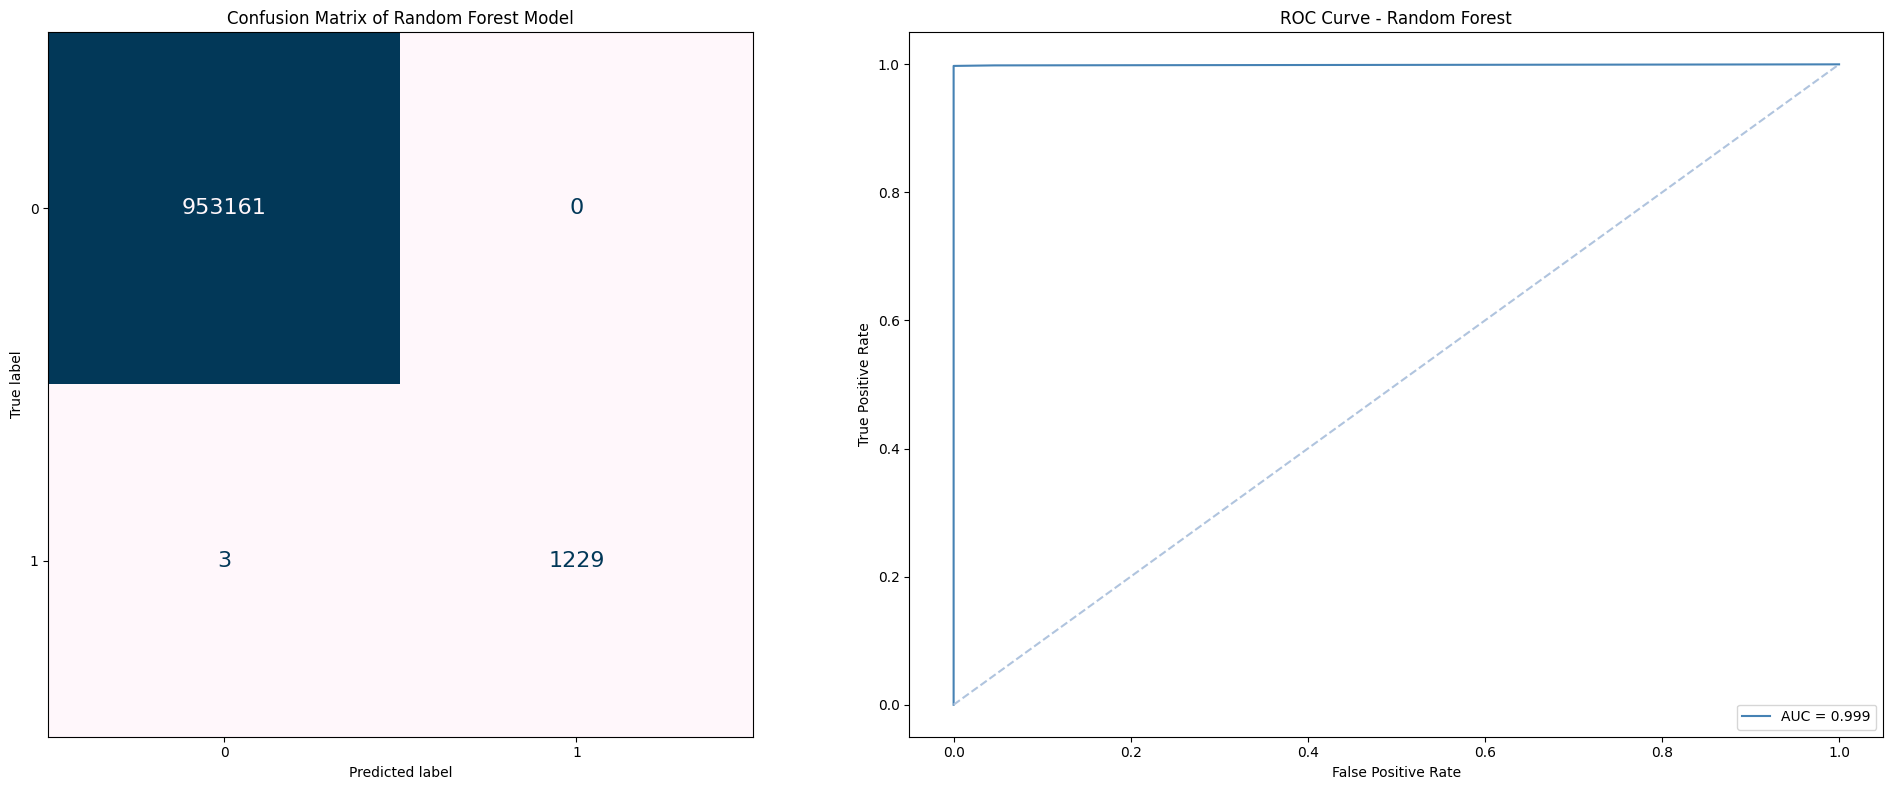

In [56]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))

# Confusion Matrix
ax[0].set_title('Confusion Matrix of Random Forest Model')
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_y_pred,
    colorbar=False,
    values_format='',
    cmap='PuBu',
    ax=ax[0],
    text_kw={'fontsize': 16}
)
ax[0].grid(False)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, rf_y_pred_score)
roc_auc = auc(fpr, tpr)

ax[1].set_title('ROC Curve - Random Forest')
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', c='steelblue')
ax[1].plot([0,1], [0,1], '--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

#### Light GBM

Text(0.5, 0, 'False Positive Rate')

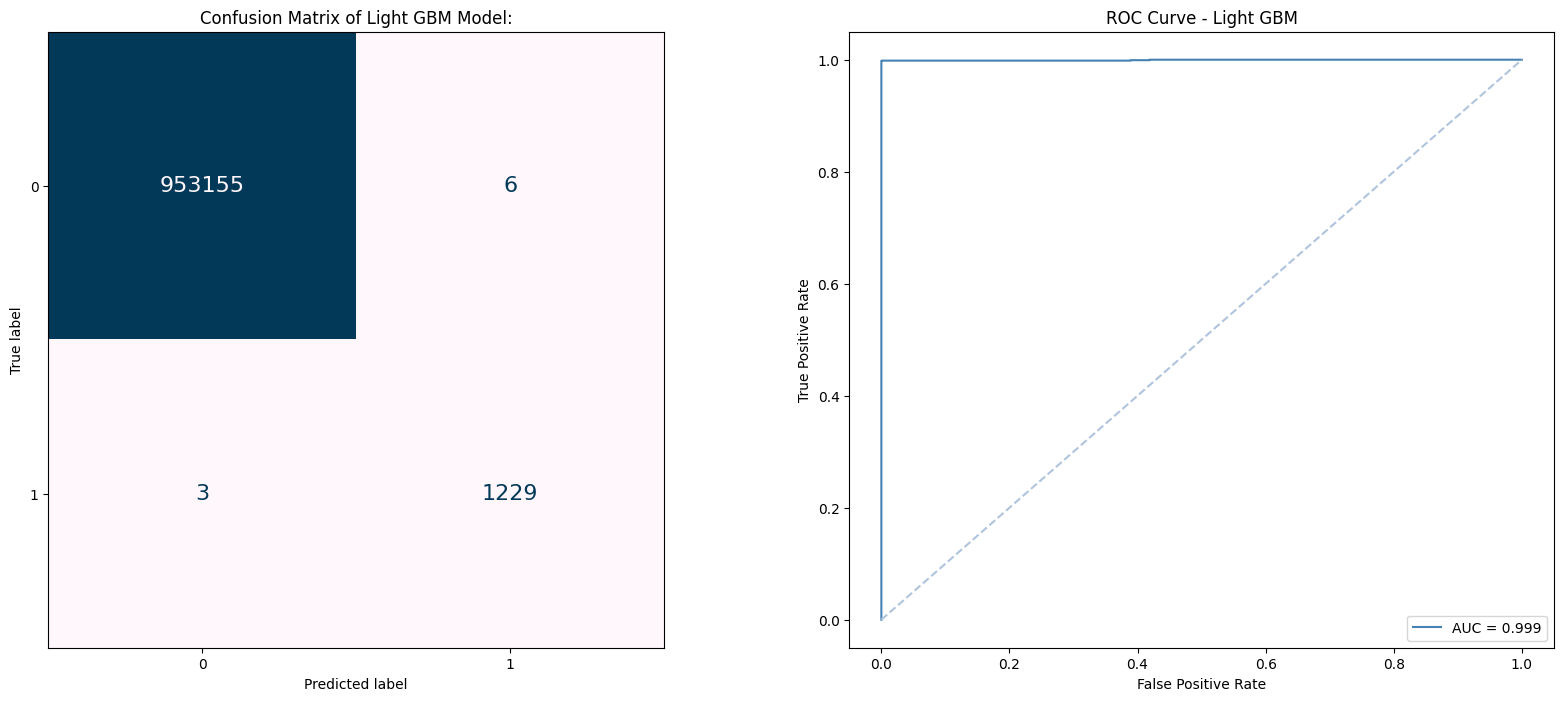

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))
ax[0].set_title('Confusion Matrix of Light GBM Model:')
ConfusionMatrixDisplay.from_predictions(y_test, lgbm_y_pred, colorbar=False, values_format='', cmap='PuBu', ax=ax[0],text_kw={'fontsize': 16})
ax[0].grid(False)


fpr, tpr, thresholds = roc_curve(y_test, lgbm_y_pred_score)
roc_auc = auc(fpr, tpr)                       
ax[1].set_title('ROC Curve - Light GBM')
ax[1].plot(fpr, tpr, label = 'AUC = %0.3f' % roc_auc, c='steelblue')
ax[1].plot([0,1],[0,1],'--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

- Note: Logistic Regression doesn't have feature importance

In [ ]:
# Random Forest
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
7   errorBalanceOrig    0.387425
3     newbalanceOrig    0.154141
2      oldbalanceOrg    0.126491
1             amount    0.071526
6   is_Merchant_Dest    0.056228
12     type_TRANSFER    0.044514
11      type_PAYMENT    0.038059
9      type_CASH_OUT    0.025252
8   errorBalanceDest    0.025230
0        hour_of_day    0.025041
5     newbalanceDest    0.023288
4     oldbalanceDest    0.021863
10        type_DEBIT    0.000942


In [ ]:
# Light GBM
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
5     newbalanceDest         982
4     oldbalanceDest         874
7   errorBalanceOrig         826
0        hour_of_day         802
1             amount         784
8   errorBalanceDest         597
2      oldbalanceOrg         498
3     newbalanceOrig         285
12     type_TRANSFER         129
9      type_CASH_OUT          99
6   is_Merchant_Dest          91
11      type_PAYMENT          26
10        type_DEBIT           7
